In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import os

%matplotlib inline

In [2]:
# plt.rcParams['font.size']      = 18
plt.rcParams['font.weight']       = 'bold'
plt.rcParams['axes.labelweight']  = 'bold'
plt.rcParams['axes.titleweight']  = 'bold'
plt.rcParams['axes.grid']      = True
plt.rcParams['axes.xmargin']   = 0
plt.rcParams['grid.linestyle'] = ':'

In [3]:
def u(t):
    """
    Unit step function.
    """
    x  = np.ones(len(t))
    tf = np.where(t < 0)
    x[tf] = 0
    return x

def chirp(f0,f1,t):
    """
    Sinusoidal chirp.
    """
    dfdt = (f1-f0)/(max(t)-min(t))
    
    chrp = np.cos(2 * np.pi * (f0*t +  0.5*dfdt*t**2)) * u(t)
    return chrp

In [4]:
# Chirp start and end frequencies
f0 = 0    # Chirp start frequency [Hz]
f1 = 5000 # Chirp start frequency [Hz]

# Start and end times
t0 = 0    # Start time [s]
t1 = 0.5  # End time [s]

# Generate time vector
dt = 0.00001         # Sampling period [s]
tt = np.arange(t0,t1,dt)

In [5]:
c1 = chirp(f0,f1,tt)
c2 = 0.707*chirp(f0,f1,tt - 1e-3)
c3 = c1 + c2

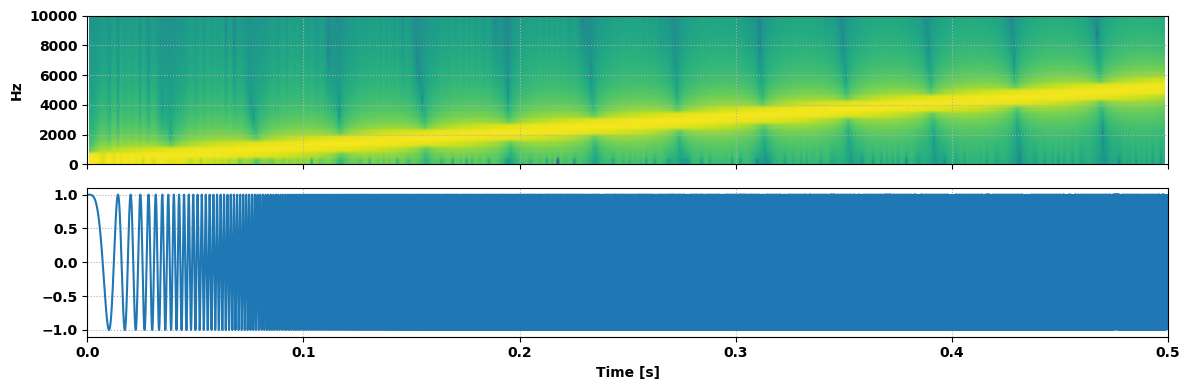

In [6]:
xlim = (0,0.5)

rows = 2
cols = 1
pinx = 0

fig = plt.figure(figsize=(12, 2*rows))

pinx += 1
ax = fig.add_subplot(rows,cols,pinx)
plt.specgram(c1,Fs=1/dt)
ax.set_xlim(xlim)
ax.set_ylim(0,10e3)
ax.set_xticklabels('')
ax.set_ylabel('Hz')

pinx += 1
ax = fig.add_subplot(rows,cols,pinx)
ax.plot(tt, c1)
ax.set_xlim(xlim)
# ax.set_xticklabels('')
ax.set_xlabel('Time [s]')

fig.tight_layout()

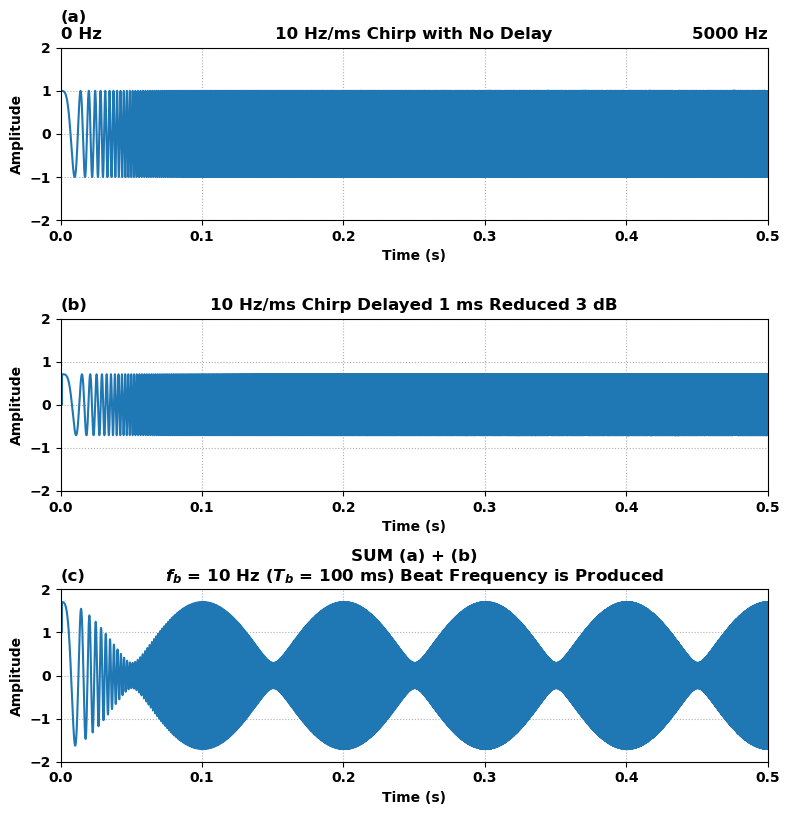

In [7]:
xlim = (0,0.5)
ylim = (-2, 2)

rows = 3
cols = 1
pinx = 0

fig = plt.figure(figsize=(8, 2.75*rows))

pinx += 1
ax = fig.add_subplot(rows,cols,pinx)
ax.plot(tt, c1)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel('Time (s)')
ax.set_title('(a)\n0 Hz',loc='left')
ax.set_title('5000 Hz'  ,loc='right')
ax.set_title('10 Hz/ms Chirp with No Delay')
ax.set_ylabel('Amplitude')


pinx += 1
ax = fig.add_subplot(rows,cols,pinx)
ax.plot(tt, c2)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel('Time (s)')
ax.set_title('(b)',loc='left')
ax.set_title('10 Hz/ms Chirp Delayed 1 ms Reduced 3 dB')
ax.set_ylabel('Amplitude')


pinx += 1
ax = fig.add_subplot(rows,cols,pinx)
ax.plot(tt, c3)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_title('(c)',loc='left')
# ax.set_title('SUM (a) + (b); 10 Hz (100 ms Period) Beat Frequency is Evident')
ax.set_title('SUM (a) + (b)\n$f_b$ = 10 Hz ($T_b$ = 100 ms) Beat Frequency is Produced')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')

bbox = dict(boxstyle='round', facecolor='white', alpha=0.9)

fig.tight_layout()
fig.savefig('fig_03.jpg',dpi=300,bbox_inches='tight')

**Caption:** Two 10 Hz/ms linear audio chirps summed with a 1 ms time delay produces a 10 Hz beat note. The 3 dB amplitude reduction of the delayed chirp simulates the amplitude loss of the longer multipath signal and shows that the summation signal has less than 100\% amplitude modulation depth.